<a href="https://colab.research.google.com/github/zlwym/IAT461_Final_Project/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Prices for Harbor Ledger Rentals**

In this project, I'll be using data collected from Airbnb listings around Boston, MA to help Harbor Ledger Rentals competitively price their rentals. The aim is to use features of rental properties, such as attributes associated with location, popularity, size, and amenities, to accurately price rental properties: not too cheap, and not too expensive. Using known prices and features of Airbnbs in the area, this project will train models on this data, focus on optimizing results, and in the end, produce a list of listings whose predicted prices are most far away from their actual prices. These listings will then be handed to the pricing manager for further review, indicating that these listings are either overpriced or underpriced and are of the highest priority for price adjustment. This project also aims to identify overpriced rental properties over underpriced rental properties, since the client has specified that charging more hurts the company more than charging less.

# EXPLORATORY DATA ANALYSIS





## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_predict,
    RandomizedSearchCV
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## Dataset Overview

As noted by the client, the price column has dollar signs and commas. It will need to be cleaned. Additionally, there are some units that have never been reviewed and these should not be removed or imputed right away. Leakage could also be an issue as many columns are depend on price, which is what I will be trying to predict.

In [ ]:
#Load the dataset
df = pd.read_csv("listings.csv")

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,52113003,https://www.airbnb.com/rooms/52113003,20260615212204,2026-06-16,city scrape,King Bed Loft in the Heart of Downtown Boston,"Welcome to our spacious, open-concept loft in ...",NaN,https://a0.muscache.com/pictures/b9802ab5-b0ef...,20828559,...,4.99,4.89,4.84,STR-516048,NaN,1,1,0,0,4.77
1,695542274861997846,https://www.airbnb.com/rooms/695542274861997846,20260615212204,2026-06-16,city scrape,Super 2 Bedroom apt in Beacon Hill Boston,Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,373675137,...,5.00,5.00,5.00,NaN,NaN,117,53,64,0,0.11
2,9110708,https://www.airbnb.com/rooms/9110708,20260615212204,2026-07-06,previous scrape,Cozy & sunny apartment BU/Allston,"Cozy 1BR, 1BA apartment in central area of All...",NaN,https://a0.muscache.com/pictures/8b1a6c2f-3135...,32018716,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
3,197972,https://www.airbnb.com/rooms/197972,20260615212204,2026-06-16,city scrape,Serene Studio in a Perfect Location,"Our 500 sf 2 room apartment is quiet, private ...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,965697,...,4.97,4.92,4.81,STR-409453,NaN,2,2,0,0,3.33
4,706445990952752456,https://www.airbnb.com/rooms/706445990952752456,20260615212204,2026-06-16,city scrape,Spacious 1br In Boston FIDI | Close to T!,This wonderful 1 bedroom apartment is located ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,382451810,...,4.91,4.91,4.63,STR-489695,NaN,43,43,0,0,4.21


I can see right off the bat that there is some "useless" data that I can drop, such as identifiers and host data. There are also some entirely null columns to drop.

In [ ]:
df.shape

(4378, 90)

There are 4378 rows and 90 columns. I will definitely not be using all 90 columns as features and will narrow these down.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4378 entries, 0 to 4377
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4378 non-null   int64  
 1   listing_url                                   4378 non-null   object 
 2   scrape_id                                     4378 non-null   int64  
 3   last_scraped                                  4378 non-null   object 
 4   source                                        4378 non-null   object 
 5   name                                          4378 non-null   object 
 6   description                                   4319 non-null   object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   4378 non-null   object 
 9   host_id                                       4378 non-null   i

In [ ]:
df.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4.378000e+03,4.378000e+03,0.0,4.378000e+03,4.360000e+03,0.0,4360.000000,4360.000000,4360.000000,4360.000000,...,3476.000000,3477.000000,3476.000000,3476.000000,0.0,4378.000000,4378.000000,4378.000000,4378.000000,3477.000000
mean,8.176489e+17,2.026062e+13,NaN,1.266426e+16,1.473194e+18,NaN,7.994725,5.775229,6.606881,5.677064,...,4.856392,4.848225,4.765570,4.625046,NaN,30.073550,24.379625,4.978986,0.009822,1.727291
std,6.442407e+17,2.375271e+00,NaN,1.453351e+17,3.387821e+16,NaN,4.064542,3.547266,4.179232,3.409409,...,0.317106,0.329988,0.327309,0.419755,NaN,52.975297,51.752829,12.400281,0.098629,1.882912
min,3.781000e+03,2.026062e+13,NaN,4.804000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,4.553112e+07,2.026062e+13,NaN,2.234822e+07,1.462889e+18,NaN,5.000000,3.000000,3.000000,3.000000,...,4.840000,4.840000,4.680000,4.520000,NaN,2.000000,1.000000,0.000000,0.000000,0.280000
50%,9.659016e+17,2.026062e+13,NaN,1.074344e+08,1.465718e+18,NaN,9.000000,6.000000,7.000000,6.000000,...,4.940000,4.940000,4.870000,4.720000,NaN,7.000000,3.000000,0.000000,0.000000,1.070000
75%,1.415532e+18,2.026062e+13,NaN,3.824518e+08,1.469716e+18,NaN,11.000000,9.000000,10.000000,9.000000,...,5.000000,5.000000,4.990000,4.860000,NaN,34.000000,19.000000,3.000000,0.000000,2.650000
max,1.706947e+18,2.026062e+13,NaN,1.694941e+18,1.706947e+18,NaN,17.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,227.000000,227.000000,64.000000,1.000000,24.160000


In [ ]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

Checking for any duplicates in the dataset.

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df['id'].duplicated().sum())

0


There are no duplicates.

## Column Selection

Not all of the columns here will be useful for predicting price per night. There are 90 columns. Not all are useful and some are duplicates. I'm going to be choosing which to keep and which to get rid of.

I will also be dropping host information. My reason for doing so is because professional rental companies do not have individual hosts the same way Airbnb does. When going through a company, you are not dealing with private homeowners. Any of the host data wouldn't be available for a professional rental company and therefore can't be used to evaluate properties where host data doesn't exist.

In [ ]:
columns = [
    "id",
    "price",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "number_of_reviews_ly",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "availability_eoy",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "amenities"
]

#Use just these columns

df = df[columns]

In [ ]:
df.shape

(4378, 30)

From 90 columns down to 29. I may remove some of these later after further analysis.

I chose these initial columns based on location, size, room type, review quality, and popularity as these are features that have impact on the price of a rental.

## Price Cleaning

In the price column, prices with more than 3 digits are expressed using a comma. Prices also have "$" before them. This is arguably the most important column, so I'll be cleaning it by removing the commas.

In [ ]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [ ]:
print(df['price'].dtype)

float64


Prices are now floats instead of objects.

## Missing Values

In [ ]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percent = (
    df.isnull()
      .mean()*100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percent": missing_percent
})

missing_df

,Missing Values,Percent
bedrooms,1261,28.803106
bathrooms,1030,23.526725
beds,929,21.219735
review_scores_checkin,902,20.603015
review_scores_value,902,20.603015
review_scores_location,902,20.603015
review_scores_accuracy,902,20.603015
review_scores_rating,901,20.580174
review_scores_communication,901,20.580174
reviews_per_month,901,20.580174


There are a lot of missing values to handle, and I can't get rid of all of them since this isn't a huge dataset. I will definitely be dropping all the null values in the price column, as this is what I'm trying to predict. Therefore, it makes no sense for me to do any kind of imputation.

In [ ]:
df = df.dropna(subset = ["price"])

In [ ]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percent = (
    df.isnull()
      .mean()*100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percent": missing_percent
})

missing_df

,Missing Values,Percent
bedrooms,1062,28.757108
review_scores_checkin,616,16.680206
review_scores_communication,616,16.680206
review_scores_location,616,16.680206
review_scores_value,616,16.680206
reviews_per_month,616,16.680206
review_scores_rating,616,16.680206
review_scores_accuracy,616,16.680206
review_scores_cleanliness,616,16.680206
bathrooms,520,14.080693


For the rest of the values, I will do median imputation. I'm doing this because removing all these values is too big a loss to the dataset. Median imputation will make the values less swayed by outliers.

Edit from second pass: I'm going to handle missing values later, since some rentals have never been reviewed.

In [ ]:
'''

df = df.fillna(
    df.median(numeric_only=True)
)

'''

'\n\ndf = df.fillna(\n    df.median(numeric_only=True)\n)\n\n'

## Distribution of Prices

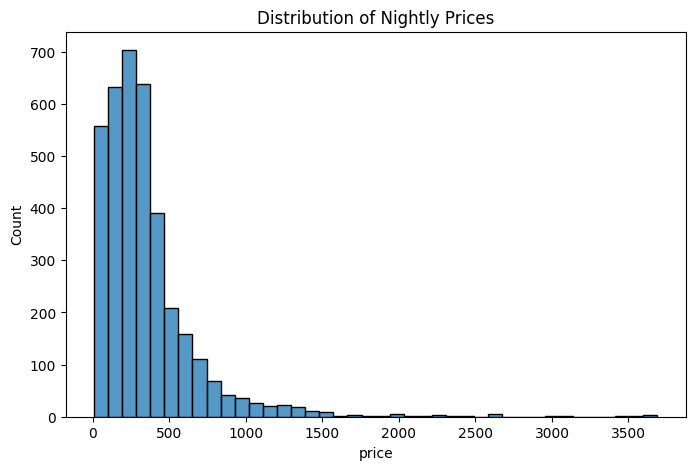

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=40)

plt.title("Distribution of Nightly Prices")

plt.show()

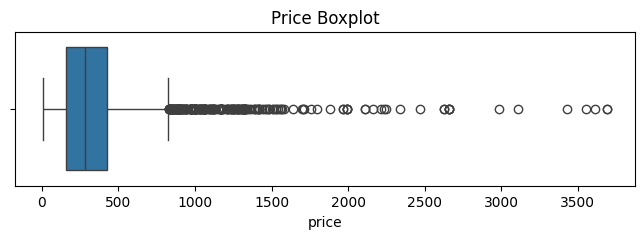

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["price"])

plt.title("Price Boxplot")

plt.show()

This data is heavily right skewed. During modeling, I'm going to test out the log transformed versus the raw data to see which performs better.

In [ ]:
df["price"].describe(percentiles=[0.90,0.95,0.99])

,price
count,3693.000000
mean,349.678708
std,330.250007
min,7.500000
50%,278.850000
90%,669.822000
95%,922.598000
99%,1558.133600
max,3689.380000


There are some outliers here including a minimum price of 7.50 and a maximum price of 3689.38. While these could definitely be possible, they are unlikely.

When I went to inspect the data, there isn't much of a difference between these ultra low and high values. The $3689 listing still has one bath, 1 bathroom, and 2 beds. However, after looking at the listing's coordinates on Google Maps, it's a private property and entire home rental right on the water in central Boston. So, this could be plausible.

Looking at the lowest prices, these rentals are mostly single rooms within residential houses. Looking up the coordinates, they are also far out of Boston's city centre.

I'm going to leave these values for now, since they are indeed possible, and return to them if needed during modeling.

## Correlation

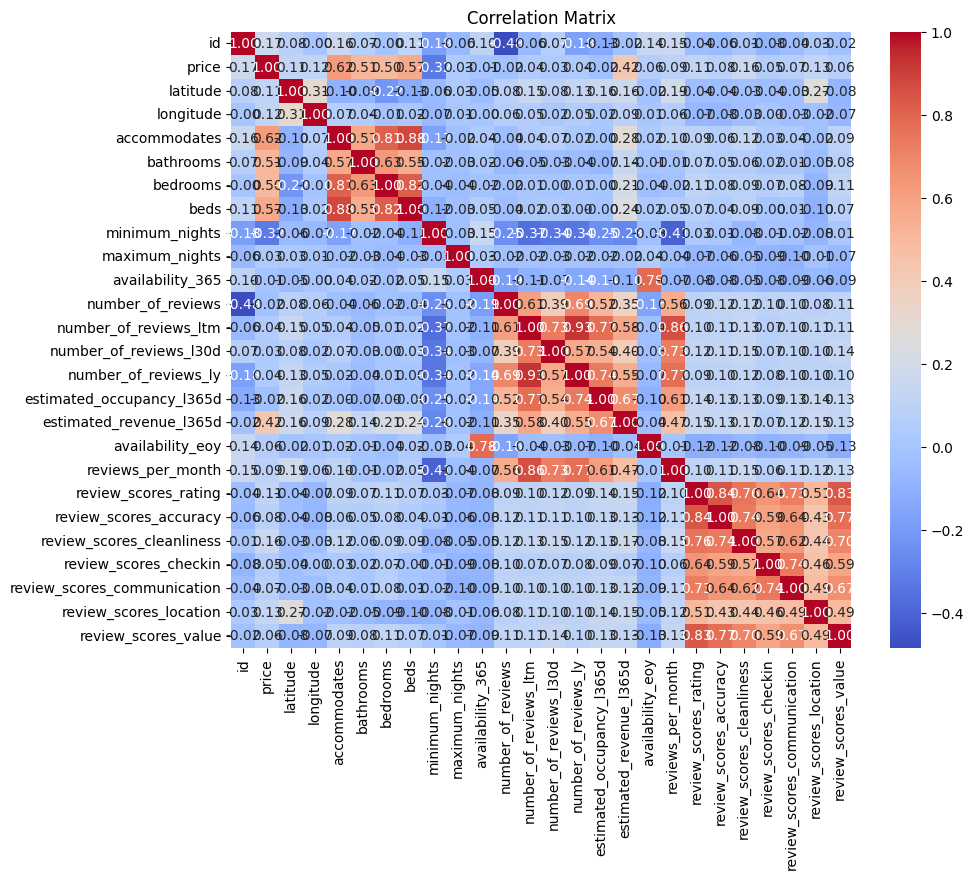

In [ ]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Looking at the correlation matrix, it seems like reviews per month and minimum nights are strongly correlated. Minimum nights seems to be correlated with a lot of features. It's interesting that some of the review categories correlate with minimum nights. As well, estimated revenue, estimated occupancy, and price are strongly correlated with minimum nights. This makes sense, because I'd presume that higher minimum nights means that people stay for longer. It likely correlates with larger occupancy properties that can accomodate more people for longer, therefore costing more.

## Some Visualizations

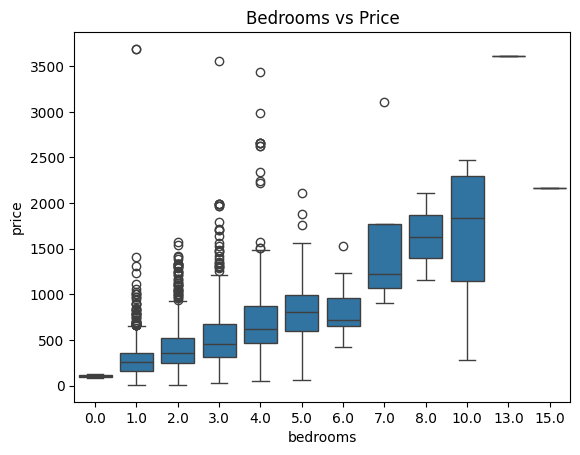

In [ ]:
sns.boxplot(
    data=df,
    x="bedrooms",
    y="price"
)

plt.title("Bedrooms vs Price")

plt.show()

It makes sense that the more bedrooms there are, the higher the price on average.

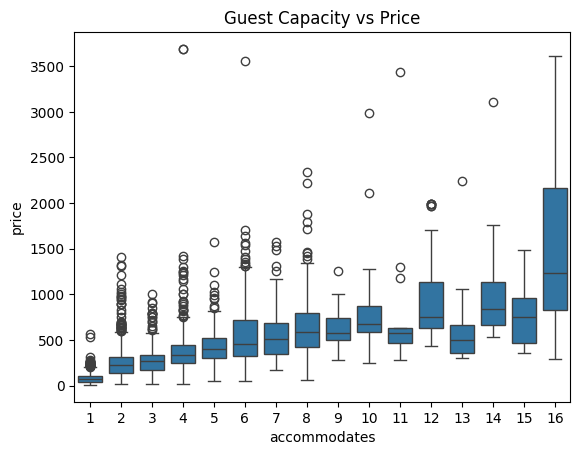

In [ ]:
sns.boxplot(
    data=df,
    x="accommodates",
    y="price"
)

plt.title("Guest Capacity vs Price")

plt.show()

Same for capacity. The higher the capacity, the higher the price is expected to be.

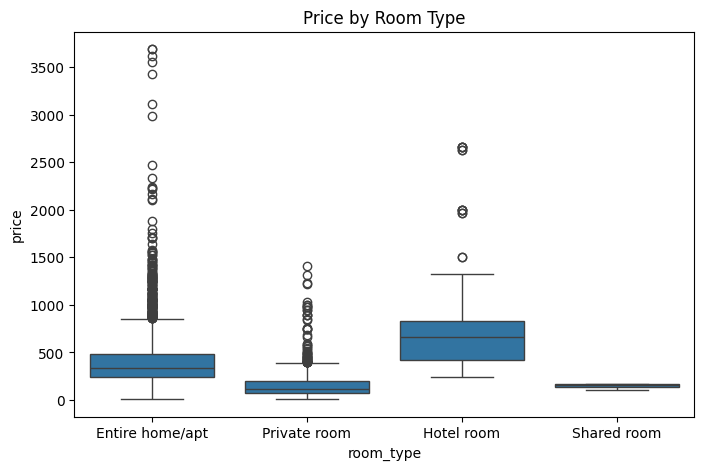

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.title("Price by Room Type")

plt.show()

Here, I would expect the entire home/apt to have the higheset pricing. However, it looks like hotel rooms on average are more expensive, while homes/apartments have higher outliers.

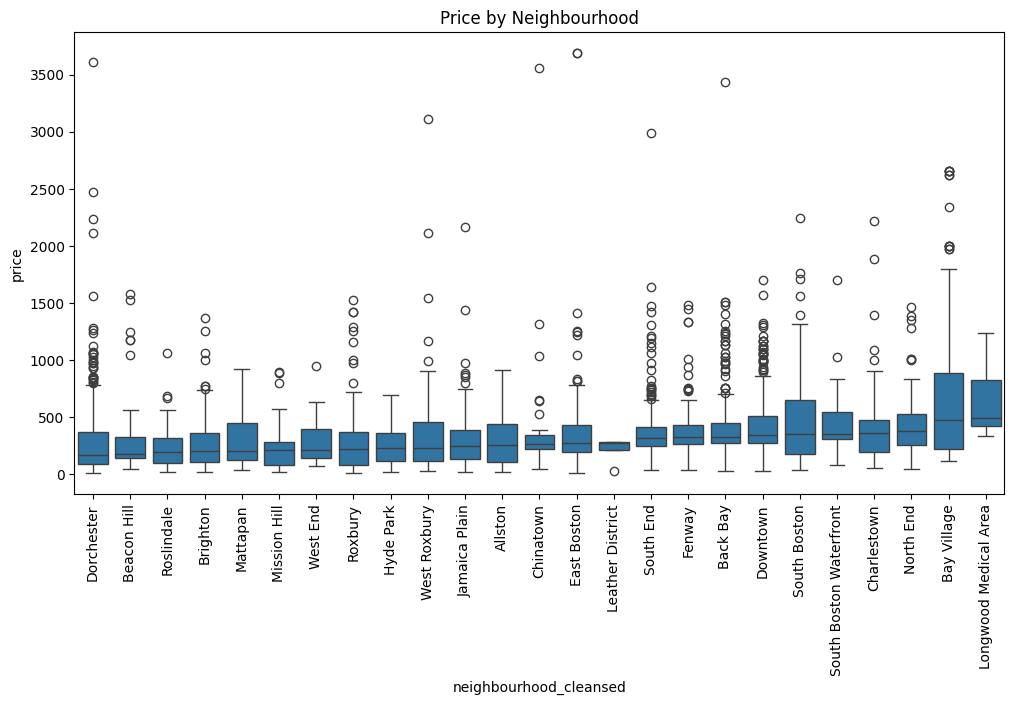

In [ ]:
plt.figure(figsize=(12,6))

order = (
    df.groupby("neighbourhood_cleansed")["price"]
      .median()
      .sort_values()
      .index
)

sns.boxplot(
    data=df,
    x="neighbourhood_cleansed",
    y="price",
    order=order
)

plt.xticks(rotation=90)

plt.title("Price by Neighbourhood")

plt.show()

Bay Village appears to be the most expensive area overall. Google also confirms that this is the most expensive neighbourhood in all of Boston.

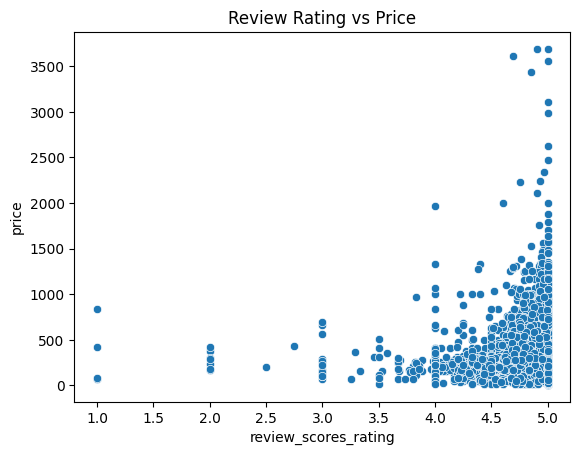

In [ ]:
sns.scatterplot(
    data=df,
    x="review_scores_rating",
    y="price"
)

plt.title("Review Rating vs Price")

plt.show()

I'm not sure if this graph just looks like this because there are more ratings for listings at lower prices or because of outliers.

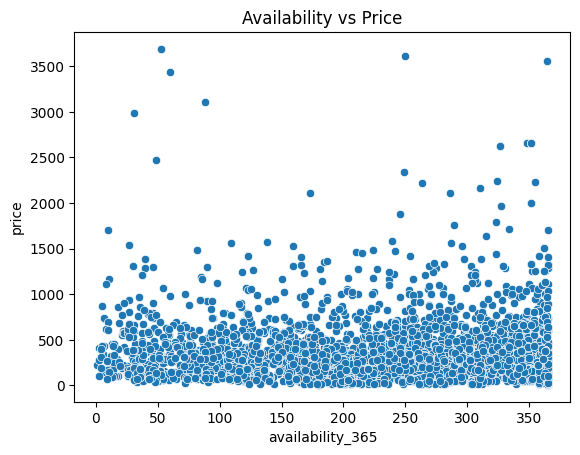

In [ ]:
sns.scatterplot(
    data=df,
    x="availability_365",
    y="price"
)

plt.title("Availability vs Price")

plt.show()

This one has no noteable patterns.

In [ ]:
df["amenity_count"] = df["amenities"].apply(
    lambda x: len(str(x).split(","))
)

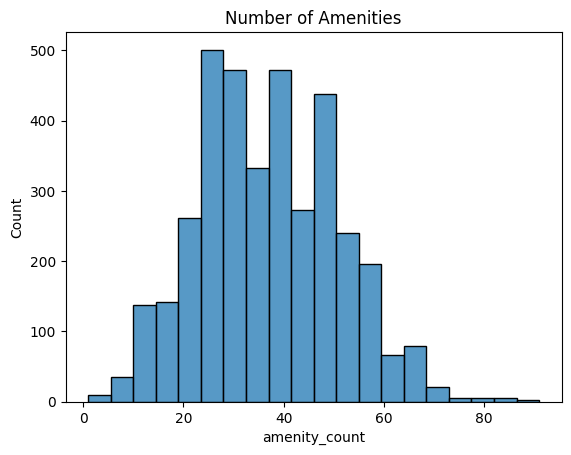

In [ ]:
sns.histplot(df["amenity_count"], bins=20)

plt.title("Number of Amenities")

plt.show()

This is the distribution of number of amenities.

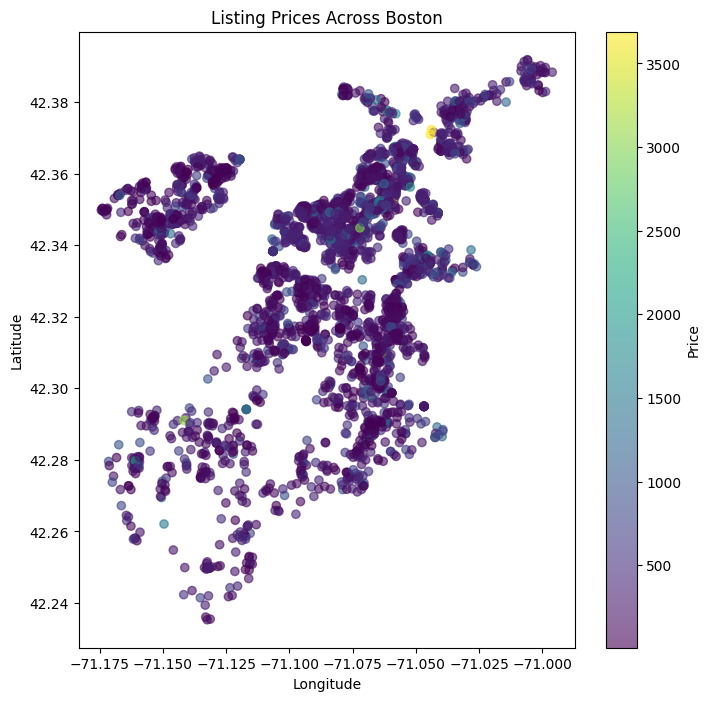

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Price")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Listing Prices Across Boston")

plt.show()

This shows areas that are densely populated with rentals and ones that are less so.

In [ ]:
corr_price = (
    numeric.corr()["price"]
    .sort_values(ascending=False)
)

corr_price

,price
price,1.000000
accommodates,0.620444
beds,0.565868
bathrooms,0.509013
bedrooms,0.500353
estimated_revenue_l365d,0.421468
id,0.167564
review_scores_cleanliness,0.159681
review_scores_location,0.128452
longitude,0.118800


## Re-evaluating Columns

I'll be getting rid of one more column, estimated revenue in the last 365 days. This is because this data depends on the price, which is what I'm trying to predict.

In [ ]:
df = df.drop(columns='estimated_revenue_l365d')

## Progress Report

For this project, I'm going to be doing supervised regression because there's one continuous numeric target outcome which is the nightly price. My objective is to have the model learn the relationship between a property's characteristics and its nightly price. These properties will be related to location, size, reviews, and availability.

So far, I have done this EDA. I first loaded the dataset into a dataframe and did an initial inspection. The dataset contained 90 columns, which is far too many to use as features. A lot of these were also irrelevant to the price, or contained host information that wouldn't be useful to an actual rental. I excluded any irrelevant information and kept only 29 columns in the end (and removed one more to make 28 later on).

I then cleaned data for the target variable of price by making the data consistent, removing $ and commas. I also checked outliers, which I deemed plausible because of their type and location. I plan on testing the model with the raw data as well as data without outliers.

I then handled missing values. For the price column, I dropped all null values. There is no point using imputation here since this is the column I'm trying to predict. For the rest of the values, I did median imputation as dropping these values would remove too much of the dataset. Median imputation as opposed to mean will reduce the chance of being impacted by outliers.

I then created visualizations to better understand the data. This will help me move on with the project as I plan on completing more data preprocessing, engineering features, and encoding categorical variables to prepare the data for machine learning. I will then split the data into training and test sets. Some models I'm thinking of using are Linear Regression, Decision Tree Regression, and Random Foreset Regression. I'll then evaluate the model.

If I have time for it, I would also like to build an interactive Streamlit app clustering listings based on features and pricing across a map.

# MODEL IMPLEMENTATION

This is going to be a supervised linear regression problem because I have a continuous numeric output determined by a set of features that can help determine the output. I want to find out the relationship that all these features have with the price.

## Copying

I'll be building a regression model that estimates nightly price of Boston rental property listings based on their characteristics. The model will be evaluated against a neighbourhood based baseline. I'm planning on using the mean absolute error (MAE) as the main evaluation metric in American dollars since this will tell me how far the model's price estimates are from the actual listed prices.

The final output will be a ranked list of listings whose current prices differ most from the model's estimated market prices.

In [ ]:
model_df = df.copy()

model_df.shape

(3693, 30)

Making a copy to use for modeling so I don't accidentally make changes to the EDA dataframe.

## Features

Removing the columns I won't be using as features as well as the price column. I have also decided to drop estimated_occupancy_l365d, since I realized this is an Airbnb specific estimate and not an actual property characteristic. For amenities, I'm using an amenity count rather than using the actual amenities as text to feed to the model.

In [ ]:
#Making numeric features for ammenities
model_df["amenity_count"] = model_df["amenities"].apply(
    lambda x: len(str(x).split(","))
)

#Features
features = [
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "number_of_reviews_ly",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "amenity_count"
]

X = model_df[features]
y = model_df["price"]

X.shape, y.shape

((3693, 25), (3693,))

## Properties With No Reviews

Up above during cleaning, I had initially done median imputation on all of the missing data. However, there are some rentals that have never been reviewed. Because of this, I'll be adding tags to the values that were originally null on top of median imputation. This way, the model can see when a property was never reviewed. I'll be using SimpleImputer to do this.

In [ ]:
'''
SimpleImputer(
    strategy = "median",
    add_indicator = True
)
'''

'\nSimpleImputer(\n    strategy = "median",\n    add_indicator = True\n)\n'

## Splitting Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 2954
Testing rows: 739


I'm using an 80/20 split here to use 80% of the dataset for training and the other 20% for testing.

## Preprocessing Pipeline

I have both numeric and categorical features here. The categorical features are neighbourhood_cleansed, room_type, and property_type. The rest will be numeric features.

In [ ]:
numeric_features = [
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "number_of_reviews_ly",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "amenity_count"
]

categorical_features = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type"
]

In [ ]:
#The median imputation with tags for orignally null values
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        )
    ]
)

#Fill missing categories and replace it with the most common category
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore" #Won't cause errors if there's a category in the test data but not the training data
            )
        )
    ]
)

#Using OneHotEncoder on categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## Neighbourhood Baseline

The client wants teh model to beat a simple baseline such as the neighbourhood average price, so I will calculate what that is. I'm going to be using the neighbourhood median instead of the mean because of the price outliers, and the median is less affected by this.

In [ ]:
#Add neighbourhood information back to the target values
baseline_train = X_train[["neighbourhood_cleansed"]].copy()
baseline_train["price"] = y_train

#Median price for each neighbourhood
neighbourhood_medians = (
    baseline_train
    .groupby("neighbourhood_cleansed")["price"]
    .median()
)

#Predict test prices using neighbourhood median
baseline_predictions = (
    X_test["neighbourhood_cleansed"]
    .map(neighbourhood_medians)
)

#If a neighbourhood wasn't in training, use the overall training median
baseline_predictions = baseline_predictions.fillna(y_train.median())

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"Baseline RMSE: ${baseline_rmse:,.2f}")
print(f"Baseline R²: {baseline_r2:.3f}")

Baseline MAE: $197.89
Baseline RMSE: $367.68
Baseline R²: -0.003


This will give me neighbourhood median baselines so I'd be able to tell the client the model's prediction compared to the baseline. The evaluation metrics tell how far away the baselines are to the actual prices on average.

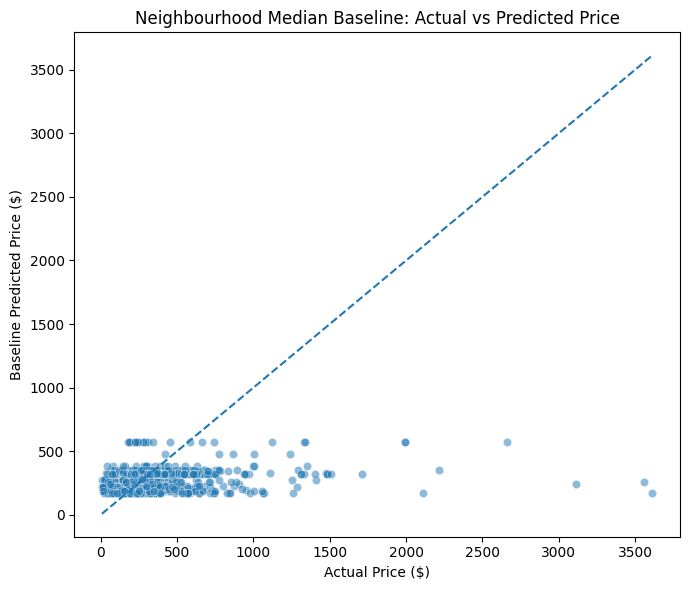

In [ ]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=baseline_predictions,
    alpha=0.5
)

# Perfect prediction line
min_price = min(y_test.min(), baseline_predictions.min())
max_price = max(y_test.max(), baseline_predictions.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Baseline Predicted Price ($)")
plt.title("Neighbourhood Median Baseline: Actual vs Predicted Price")

plt.tight_layout()
plt.show()

This is a visualization of perfect predictions (diagonal line) to the neighbourhood baseline.

In [ ]:
neighbourhood_medians = (
    X_train.assign(price=y_train)
    .groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values(ascending=False)
)

neighbourhood_medians

,price
neighbourhood_cleansed,
Bay Village,574.000
Longwood Medical Area,478.000
North End,382.010
Charlestown,354.710
Downtown,350.000
South Boston Waterfront,344.320
South End,327.000
Back Bay,322.000
South Boston,320.000


Going to plot out the baseline prices for each neighbourhood, because it would be useful and also interesting.

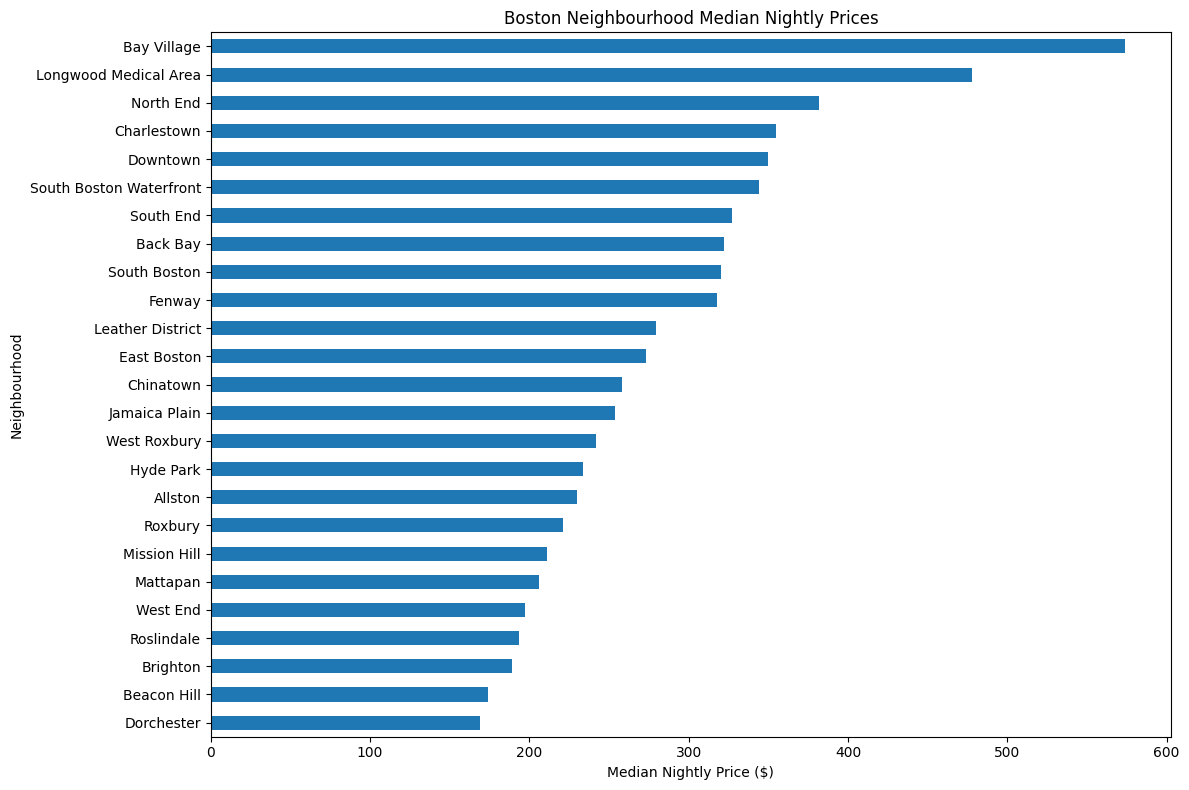

In [ ]:
plt.figure(figsize=(12, 8))

neighbourhood_medians.sort_values().plot(
    kind="barh"
)

plt.xlabel("Median Nightly Price ($)")
plt.ylabel("Neighbourhood")
plt.title("Boston Neighbourhood Median Nightly Prices")
plt.tight_layout()

plt.show()

I'm going to add an out of fold baseline too. I'm introducing crossvalidation here so that the model isn't prediting listings it's already seen when I train on all the data.

In [ ]:
#5 fold crossvalidation (5 or 10 seems pretty standard)
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

baseline_oof_predictions = np.zeros(len(y))

for train_idx, val_idx in kf.split(X):

    X_fold_train = X.iloc[train_idx]
    X_fold_val = X.iloc[val_idx]

    y_fold_train = y.iloc[train_idx]
    y_fold_val = y.iloc[val_idx]

    #Calculate neighbourhood medians using only the fold's training data
    fold_medians = (
        X_fold_train.assign(price=y_fold_train)
        .groupby("neighbourhood_cleansed")["price"]
        .median()
    )

    #Predict the validation fold
    fold_predictions = (
        X_fold_val["neighbourhood_cleansed"]
        .map(fold_medians)
        .fillna(y_fold_train.median())
    )

    baseline_oof_predictions[val_idx] = fold_predictions

baseline_cv_mae = mean_absolute_error(
    y,
    baseline_oof_predictions
)

baseline_cv_rmse = np.sqrt(
    mean_squared_error(
        y,
        baseline_oof_predictions
    )
)

baseline_cv_r2 = r2_score(
    y,
    baseline_oof_predictions
)

print(f"5-Fold Baseline MAE: ${baseline_cv_mae:,.2f}")
print(f"5-Fold Baseline RMSE: ${baseline_cv_rmse:,.2f}")
print(f"5-Fold Baseline R²: {baseline_cv_r2:.3f}")

5-Fold Baseline MAE: $187.42
5-Fold Baseline RMSE: $330.13
5-Fold Baseline R²: 0.000


## Linear Regression

Training linear regression

In [ ]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

Evaluating linear regression

In [ ]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print(f"Linear Regression MAE: ${linear_mae:,.2f}")
print(f"Linear Regression RMSE: ${linear_rmse:,.2f}")
print(f"Linear Regression R²: {linear_r2:.3f}")

Linear Regression MAE: $132.48
Linear Regression RMSE: $239.83
Linear Regression R²: 0.573


The model is off by A LOT from the calculated. I'm going to need to make a lot of changes.

## Decision Tree

Training decision tree

In [ ]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=10,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

tree_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(X_test)

Evaluate linear regression

In [ ]:
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print(f"Decision Tree MAE: ${tree_mae:,.2f}")
print(f"Decision Tree RMSE: ${tree_rmse:,.2f}")
print(f"Decision Tree R²: {tree_r2:.3f}")

Decision Tree MAE: $122.43
Decision Tree RMSE: $244.51
Decision Tree R²: 0.557


## Random Forest

Training random forest

In [ ]:
forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forest_model.fit(
    X_train,
    y_train
)

forest_predictions = forest_model.predict(X_test)

Evaluating random forest

In [ ]:
forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_predictions
    )
)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print(f"Random Forest MAE: ${forest_mae:,.2f}")
print(f"Random Forest RMSE: ${forest_rmse:,.2f}")
print(f"Random Forest R²: {forest_r2:.3f}")

Random Forest MAE: $102.22
Random Forest RMSE: $216.08
Random Forest R²: 0.654


## Results

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Neighbourhood Median Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE ($)": [
        baseline_mae,
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE ($)": [
        baseline_rmse,
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

results.sort_values("MAE ($)")

,Model,MAE ($),RMSE ($),R²
3,Random Forest,102.217470,216.082708,0.653727
2,Decision Tree,122.426534,244.513196,0.556613
1,Linear Regression,132.478507,239.828428,0.573440
0,Neighbourhood Median Baseline,197.886225,367.675137,-0.002553


All of these models are over $100 off from the neighbourhood baselines which means I'll have to do some investigating. I will need to find out if they're off because they are much more accurate than the neighbourhood baseline, or if it's because they're just wrong.

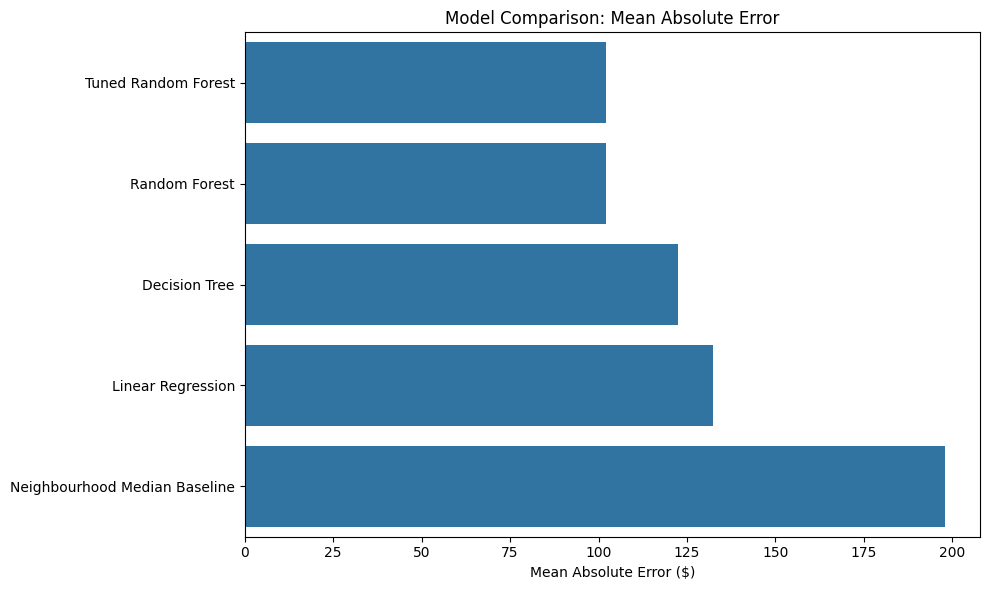

In [ ]:
plt.figure(figsize=(10, 6))

plot_data = results.sort_values("MAE ($)")

sns.barplot(
    data=plot_data,
    x="MAE ($)",
    y="Model"
)

plt.xlabel("Mean Absolute Error ($)")
plt.ylabel("")
plt.title("Model Comparison: Mean Absolute Error")

plt.tight_layout()
plt.show()

A visualization of all the models and how they stack up to one another in terms of MAE, my primary evaluation metric.

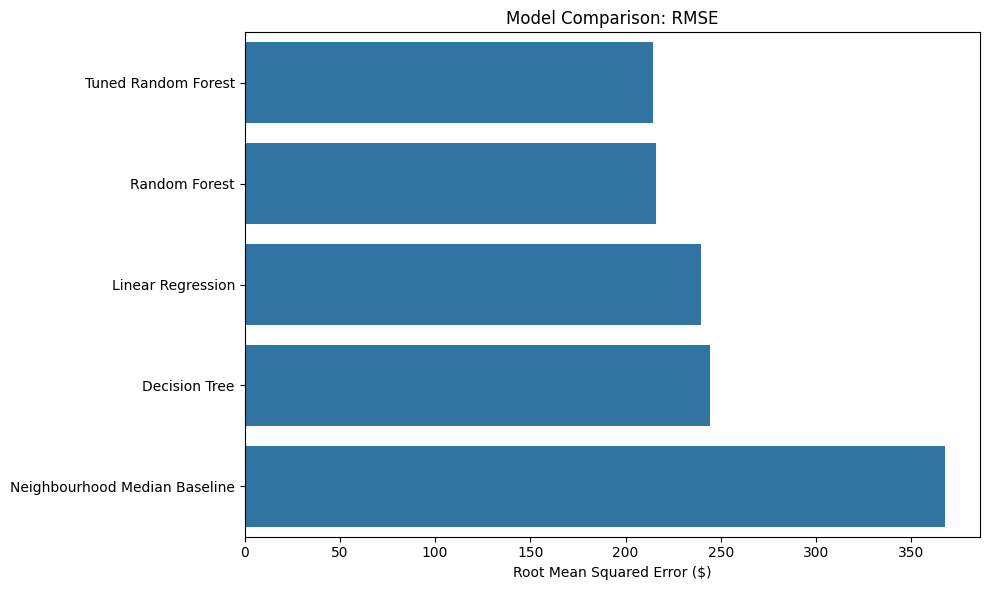

In [ ]:
plt.figure(figsize=(10, 6))

plot_data = results.sort_values("RMSE ($)")

sns.barplot(
    data=plot_data,
    x="RMSE ($)",
    y="Model"
)

plt.xlabel("Root Mean Squared Error ($)")
plt.ylabel("")
plt.title("Model Comparison: RMSE")

plt.tight_layout()
plt.show()

This graph shows a comparison of each model's RSME.

## Model Versus Baseline

The random forest model has performed the best so far. Compared to the baseline's MAE of 197.89, random forest had a MAE of 102.22.

In [ ]:
best_model_mae = forest_mae  # change if another model performs better

improvement = (
    (baseline_mae - best_model_mae)
    / baseline_mae
) * 100

print(
    f"The random forest model improves MAE over the baseline "
    f"by {improvement:.1f}%."
)

The random forest model improves MAE over the baseline by 48.3%.


## Hyperparameter Tuning

The initial random forest performed the best but could be improved since I chose the hyperparameters myself. I'll be using RandomizedSearchCV with 5 fold crossvalidation to see if I can find a better combination of hyperparameters. I'll keep evaluating using MAE.

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

#Hyperparameter searching
param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": [1.0, "sqrt"]
}

#5 fold crossvalidation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=15,    #15 iterations... tried 30 and computer couldn't take it
    scoring="neg_mean_absolute_error",
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(add_indicator=True,
                                                                                                              strategy='median'))]),
                                                                               ['latitude',
                                                                                'longitude',
                                                                                'accommodates',
                                                                                'bathrooms',
                                                                                'bedrooms',
                                                                                'beds',
                                                                                'minimum_nights',
                                                                                'maximum_nights',
                                                                                'availability_3...
                                                                                'property_type'])])),
                                             ('model',
                                              RandomForestRegressor(n_jobs=1,
                                                                    random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [10, 15, 20, None],
                                        'model__max_features': [1.0, 'sqrt'],
                                        'model__min_samples_leaf': [1, 2, 5],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=2)

In [ ]:
print("Best parameters:")
print(random_search.best_params_)

print(
    f"\nBest cross-validation MAE: "
    f"${-random_search.best_score_:,.2f}"   #negative because MAE comes out as negative first
)

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 1.0, 'model__max_depth': 15}

Best cross-validation MAE: $96.55


Above is the hyperparameters that won. Now, I will look at the MAE, RSME, and R^2 that the tuned model give.

In [ ]:
tuned_model = random_search.best_estimator_

tuned_predictions = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print(f"Tuned Random Forest MAE: ${tuned_mae:,.2f}")
print(f"Tuned Random Forest RMSE: ${tuned_rmse:,.2f}")
print(f"Tuned Random Forest R²: {tuned_r2:.3f}")

Tuned Random Forest MAE: $102.00
Tuned Random Forest RMSE: $214.36
Tuned Random Forest R²: 0.659


So the tuning improved the model very slightly, but any improvement I will gladly take. Here's a comparison of the tuned model with the median baseline:

In [ ]:
tuned_improvement = (
    (baseline_mae - tuned_mae)
    / baseline_mae
) * 100

print(
    f"Tuned Random Forest improves over the "
    f"neighbourhood median baseline by "
    f"{tuned_improvement:.1f}%."
)

Tuned Random Forest improves over the neighbourhood median baseline by 48.5%.


This is 48.5% as compared to 48.3% with the original model. Very slight but still an improvement. Looking at the data, I have decided to deem $102 an acceptable MAE for model performance, considering that listings worth thousands of dollars per night skew this number.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Neighbourhood Median Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE ($)": [
        baseline_mae,
        linear_mae,
        tree_mae,
        forest_mae,
        tuned_mae
    ],
    "RMSE ($)": [
        baseline_rmse,
        linear_rmse,
        tree_rmse,
        forest_rmse,
        tuned_rmse
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        tree_r2,
        forest_r2,
        tuned_r2
    ]
})

results.sort_values("MAE ($)")

,Model,MAE ($),RMSE ($),R²
4,Tuned Random Forest,101.998358,214.360731,0.659224
3,Random Forest,102.217470,216.082708,0.653727
2,Decision Tree,122.426534,244.513196,0.556613
1,Linear Regression,132.478507,239.828428,0.573440
0,Neighbourhood Median Baseline,197.886225,367.675137,-0.002553


This is a comparison of all the models I tried and the tuned random forest model that is my winner. It has the lowest MAE and RMSE, and R^2 closest to 1. The MAE of $102 means that on average, the model's predictions are this amount away from the actual price. RMSE is a similar metric that is more swayed by mistakes. R^2 is the model's predictive accuracy, and having close to 1 means higher accuracy. Therefore, it performs the best.

## Choice of Model

I've compared the models uing MAE, RMSE, and R^2. I've used MAE as the primary evaluation metric because the client wants pricing accuracy in dollars. Lower MAE means the nightly price is closer to the actual listed nightly price on average. The random forest model has the lowest MAE and also shows improvement from the neighbourhood baseline.

After deciding on the random forest model, I used RandomizedSearchCV with 5 fold crossvalidation to test different hyperparameter combinations. The tuned version was evaluated on the held out test set after I selected the hyperparameters. This is because I wanted the model to make predictions on listings it hasn't seen before, instead of fitting on all the data. I'm going to be using this tuned version of the model moving forward.

## Out of Fold Pricing Estimates

The deliverable is a ranking of listings which have current prices furthest away from predicted prices. I will be generating out of fold predictions as a way for the model to make predictions on listings it hasn't already seen.

In [ ]:
#Out of fold predictions using the tuned model
oof_predictions = cross_val_predict(
    tuned_model,
    X,
    y,
    cv=kf,
    n_jobs=-1
)

model_df["estimated_price"] = oof_predictions

Next I'll evaluate the out of fold pricing predictions.

In [ ]:
oof_mae = mean_absolute_error(
    y,
    oof_predictions
)

oof_rmse = np.sqrt(
    mean_squared_error(
        y,
        oof_predictions
    )
)

oof_r2 = r2_score(
    y,
    oof_predictions
)

print(f"Out-of-Fold MAE: ${oof_mae:,.2f}")
print(f"Out-of-Fold RMSE: ${oof_rmse:,.2f}")
print(f"Out-of-Fold R²: {oof_r2:.3f}")

Out-of-Fold MAE: $95.75
Out-of-Fold RMSE: $194.43
Out-of-Fold R²: 0.653


Even more improvement!

## Pricing Differences

Here, I'll calculate the difference between the estimated prices and the actual prices.

In [ ]:
model_df["price_difference"] = (
    model_df["price"] -
    model_df["estimated_price"]
)

model_df["absolute_difference"] = (
    model_df["price_difference"].abs()
)

## Ranked List

I want to now show the listings in order of largest difference in price to smallest difference in price.

In [ ]:
pricing_shortlist = (
    model_df[
        [
            "id",
            "neighbourhood_cleansed",
            "room_type",
            "property_type",
            "accommodates",
            "bedrooms",
            "bathrooms",
            "price",
            "estimated_price",
            "price_difference",
            "absolute_difference"
        ]
    ]
    .sort_values(
        "absolute_difference",
        ascending=False
    )
)

pricing_shortlist.head(20)

,id,neighbourhood_cleansed,room_type,property_type,accommodates,bedrooms,bathrooms,price,estimated_price,price_difference,absolute_difference
1258,1403976415694244973,East Boston,Entire home/apt,Entire rental unit,4,1.0,1.0,3689.38,1431.690589,3415.181528,3415.181528
2548,1654593861392112317,East Boston,Entire home/apt,Entire rental unit,4,1.0,1.0,3689.38,1508.510555,3315.493205,3315.493205
3420,1220559061762913883,Chinatown,Entire home/apt,Entire rental unit,6,3.0,NaN,3556.67,1596.456061,2836.318307,2836.318307
2601,32302374,Back Bay,Entire home/apt,Entire townhouse,11,4.0,3.5,3432.00,2043.335477,2199.413502,2199.413502
4197,1287842499954127508,South End,Entire home/apt,Entire home,10,4.0,NaN,2988.33,1565.180343,2153.670922,2153.670922
1605,17472272,West Roxbury,Entire home/apt,Entire home,14,7.0,4.0,3110.66,2136.567481,1929.157825,1929.157825
1921,33638927,Dorchester,Entire home/apt,Entire home,16,13.0,6.0,3614.00,2424.865655,1761.305550,1761.305550
1555,1156624218560798027,West Roxbury,Entire home/apt,Entire rental unit,10,5.0,2.0,2112.00,1081.313755,1442.134318,1442.134318
3932,4410765,Brighton,Entire home/apt,Entire home,5,3.0,NaN,98.89,1132.671685,-1341.229003,1341.229003
884,552968006314520018,Dorchester,Entire home/apt,Entire place,16,8.0,NaN,2108.00,1270.899239,1258.308593,1258.308593


## Renaming Columns

Renaming columns to make them easier to understand for the client.

In [ ]:
pricing_shortlist = pricing_shortlist.rename(
    columns={
        "id" : "Listing ID",
        "neighbourhood_cleansed": "Neighbourhood",
        "room_type": "Room Type",
        "property_type": "Property Type",
        "accommodates": "Guests",
        "bedrooms": "Bedrooms",
        "bathrooms": "Bathrooms",
        "price": "Current Price",
        "estimated_price": "Estimated Price",
        "price_difference": "Price Difference",
        "absolute_difference": "Absolute Difference"
    }
)

pricing_shortlist.head(20)

,Listing ID,Neighbourhood,Room Type,Property Type,Guests,Bedrooms,Bathrooms,Current Price,Estimated Price,Price Difference,Absolute Difference
1258,1403976415694244973,East Boston,Entire home/apt,Entire rental unit,4,1.0,1.0,3689.38,1431.690589,3415.181528,3415.181528
2548,1654593861392112317,East Boston,Entire home/apt,Entire rental unit,4,1.0,1.0,3689.38,1508.510555,3315.493205,3315.493205
3420,1220559061762913883,Chinatown,Entire home/apt,Entire rental unit,6,3.0,NaN,3556.67,1596.456061,2836.318307,2836.318307
2601,32302374,Back Bay,Entire home/apt,Entire townhouse,11,4.0,3.5,3432.00,2043.335477,2199.413502,2199.413502
4197,1287842499954127508,South End,Entire home/apt,Entire home,10,4.0,NaN,2988.33,1565.180343,2153.670922,2153.670922
1605,17472272,West Roxbury,Entire home/apt,Entire home,14,7.0,4.0,3110.66,2136.567481,1929.157825,1929.157825
1921,33638927,Dorchester,Entire home/apt,Entire home,16,13.0,6.0,3614.00,2424.865655,1761.305550,1761.305550
1555,1156624218560798027,West Roxbury,Entire home/apt,Entire rental unit,10,5.0,2.0,2112.00,1081.313755,1442.134318,1442.134318
3932,4410765,Brighton,Entire home/apt,Entire home,5,3.0,NaN,98.89,1132.671685,-1341.229003,1341.229003
884,552968006314520018,Dorchester,Entire home/apt,Entire place,16,8.0,NaN,2108.00,1270.899239,1258.308593,1258.308593


## Recommendation for Client

The goal of this project is to give suggestions to the client on how to reprice listings. I will add on a column that suggests whether to increase or decrease the listed price depending on the difference between estimated and actual.

In [ ]:
pricing_shortlist["Recommendation"] = np.where(
    pricing_shortlist["Price Difference"] > 0,
    "Review for possible price reduction",    #Reduce if estimated price < actual price
    "Review for possible price increase"      #Increase if estimated price > actual price
)

In [ ]:
pricing_shortlist.head(20)

,Listing ID,Neighbourhood,Room Type,Property Type,Guests,Bedrooms,Bathrooms,Current Price,Estimated Price,Price Difference,Absolute Difference,Recommendation
1258,1403976415694244973,East Boston,Entire home/apt,Entire rental unit,4,1.0,1.0,3689.38,1431.690589,3415.181528,3415.181528,Review for possible price reduction
2548,1654593861392112317,East Boston,Entire home/apt,Entire rental unit,4,1.0,1.0,3689.38,1508.510555,3315.493205,3315.493205,Review for possible price reduction
3420,1220559061762913883,Chinatown,Entire home/apt,Entire rental unit,6,3.0,NaN,3556.67,1596.456061,2836.318307,2836.318307,Review for possible price reduction
2601,32302374,Back Bay,Entire home/apt,Entire townhouse,11,4.0,3.5,3432.00,2043.335477,2199.413502,2199.413502,Review for possible price reduction
4197,1287842499954127508,South End,Entire home/apt,Entire home,10,4.0,NaN,2988.33,1565.180343,2153.670922,2153.670922,Review for possible price reduction
1605,17472272,West Roxbury,Entire home/apt,Entire home,14,7.0,4.0,3110.66,2136.567481,1929.157825,1929.157825,Review for possible price reduction
1921,33638927,Dorchester,Entire home/apt,Entire home,16,13.0,6.0,3614.00,2424.865655,1761.305550,1761.305550,Review for possible price reduction
1555,1156624218560798027,West Roxbury,Entire home/apt,Entire rental unit,10,5.0,2.0,2112.00,1081.313755,1442.134318,1442.134318,Review for possible price reduction
3932,4410765,Brighton,Entire home/apt,Entire home,5,3.0,NaN,98.89,1132.671685,-1341.229003,1341.229003,Review for possible price increase
884,552968006314520018,Dorchester,Entire home/apt,Entire place,16,8.0,NaN,2108.00,1270.899239,1258.308593,1258.308593,Review for possible price reduction


This is the final deliverable for the client: A list of the rentals that need to be looked at for price adjustment by the pricing manager. It includes the property identifier, its attributes, estimated versus actual price, and suggestion for repricing.

# APPENDIX

## Executive Summary

Harbour Ledger Rentals is a fictional company, a small firm in Boston that manages about 200 rental units for owners. Currently, the company sets nightly pricing manually using their own judgement and market research. The company aims to use data about similar listings in the market to better and more consistently price their units, using characteristics of the properties.

In this project, Airbnb data from the Boston area captured in 2026 is used as a benchmark for Harbour Ledger Rental's pricing. I developed a supervised regression system to provide the pricing manager with a pricing reference and identify which listings need to be repriced first: listings whose estimated price is furthest away from their actual price. Rental characteristics such as location, type, size, capacity, availability, and popularity were used to build a relationship with nightly price.

I tested three different models against a median-based neighbourhood average. The random forest model performed the best with a MAE (mean absolute error) of 102 dollars as opposed to the baseline's 198 dollars. This means that as opposed to predicting 198 dollars away from the actual price on average with baseline, the model predicted only 102 dollars away from the actual price. This was my primary evaluation metric for success.

In the end, the model shouldn't be used as an actual pricing system. It's meant to be used as a tool to support decision making when it comes to pricing, identifying if a listing is potentially overpriced or underpriced.

The deliverable for Harbour Ledger Rentals is therefore a ranked list of listings to be reviewed, from highest priority to lowest. This means that the list is ordered by largest difference between the estimated price and the actual price. The purpose of this is to provide the pricing manager with an idea of what to look at first.

Again, the purpose of this project is to use the model as pricing decision support as opposed to a repricing machine. It can support good business decisions, but should not be used in place of a pricing manager.

## Assumptions Log

Assumption 1: The target variable is nightly price.

The goal of this whole project was to estimate what a listing should cost per night based on its features, so I decided that price was the continuous target variable.

Assumption 2: The Airbnb Boston dataset is a good benchmark for Harbor Ledger Rental's market.

This company is fictional and therefore I have assumed that the company wants their prices to be comparable to Airbnbs, and that they exist within the same market.

Assumption 3: The model should only use information that's available for Harbor Ledger Rental's properties.

Identifiers and URLs were not used in modeling, or any fields, such as host information, that are Airbnb specific and would not be available to a rental company.

Assumption 4: Missing information, such as reviews, doesn't necessarily mean that a listing is poor quality.

Listings with no reviews were treated as new or unrated rather than being removed. These were handled through the modeling pipeline instead of assuming no review meant a low review.

Assumption 5: The heavily right skewed price distribution was investigated instead of transformed right away. I considered log transforming this data as opposed to using the raw dtat. However, my final approach used the raw data because I thought it would be more realistic. Using raw data meant my original units were kept, which the client wanted, and allowed for absolute interpretation.

## Limitations

Firstly, the dataset is just a 2026 snapshot of Boston Airbnb data. There's no historical pricing, and rental prices can change based on the season. This project might benefit from Airbnb data over time in the Boston market.

The model's predictions also don't predict optimal price, just price based off the Airbnb market. So, the model's predictions of overpriced/underpriced could still potentially lead to loss for the business.

Amenities were also not modeled as thoroughly as they could have been. The raw data has different amenities, but since I converted these into a count rather than their actual meanings, some of the data is "dumbed down".



## Links

Video walkthrough on youtube:
[Video](https://youtu.be/MJhDnNs0DnQ)

Streamlit app:

## Removed Code

This section is for code and markdowns I had but removed.

The following portion was removed because I realized these Airbnb listings aren't actually properties of Harbor Ledger Rentals. Therefore, I shouldn't be evaluating the model on data it's already seen, the client is more interested on how it would react to listings it hasn't seen yet. Because of this, I ended up evaluating on data out of fold. This is more realistic to how the model would work when predicting prices on Harbour Ledger Rental's properties.

### Fitting on All Data

The client wants to know which listings they should look at, so I'll be producing a list of listings with the most significant differences between their current price and estimated price.

In [ ]:
#Fit the random forest model on all data
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

final_model.fit(
    X,
    y
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median'))]),
                                                  ['latitude', 'longitude',
                                                   'accommodates', 'bathrooms',
                                                   'bedrooms', 'beds',
                                                   'minimum_nights',
                                                   'maximum_nights',
                                                   'availability_365',
                                                   'number_of_reviews',
                                                   'number_of_reviews_ltm',
                                                   'number_of_reviews_l30d',
                                                   'numbe...
                                                   'review_scores_location',
                                                   'review_scores_value',
                                                   'amenity_count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['neighbourhood_cleansed',
                                                   'room_type',
                                                   'property_type'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=3,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

I will then generate an estimate for every listing.

In [ ]:
model_df["estimated_price"] = final_model.predict(X)